In [2]:
import os

import numpy as np

import matplotlib.pyplot as plt 

import tensorflow as tf
import tf_keras as keras 
from tf_keras import layers, models, callbacks

from qkeras import QActivation, QConv2D, QDense
from qkeras import quantized_bits, quantized_relu
from qkeras.utils import model_save_quantized_weights

import hls4ml


In [3]:
# Set up quantization params
W = quantized_bits(bits=8, integer=0, alpha=1) # Weights are small, so range is -1 to 1
A = "quantized_relu(8,2)" # give relu range up to 4.0
A_OUT = "quantized_bits(8,1)"

In [5]:
def build_q_tiny_autoencoder(input_shape=(64, 64, 1)):
    input_img = layers.Input(shape=input_shape)
 
    # Encoder 
    x = QConv2D(8, (3, 3), padding="same",
                kernel_quantizer=W, bias_quantizer=W,
                name="enc_conv1")(input_img)
    x = QActivation(A, name="enc_act1")(x)
    x = layers.MaxPooling2D((2, 2), padding="same", name="enc_pool1")(x)
 
    x = QConv2D(4, (3, 3), padding="same",
                kernel_quantizer=W, bias_quantizer=W,
                name="enc_conv2")(x)
    x = QActivation(A, name="enc_act2")(x)
    x = layers.MaxPooling2D((2, 2), padding="same", name="enc_pool2")(x)
 
    # Latent space
    shape_before_flattening = tf.keras.backend.int_shape(x)[1:]

    # Using explicit reshape instead of flatten to avoid missing ops when compiling with hls4ml
    flat_dim = int(np.prod(shape_before_flattening)) 
    x = layers.Reshape((flat_dim,), name="flatten")(x)


    latent_space = QDense(32, kernel_quantizer=W, bias_quantizer=W,
                          name="latent_space")(x)
 
    # Decoder
    dense_shape = int(np.prod(shape_before_flattening))
    x = QDense(dense_shape, kernel_quantizer=W, bias_quantizer=W,
               name="dec_dense")(latent_space)
    x = layers.Reshape(shape_before_flattening, name="dec_reshape")(x)
 
    x = QConv2D(4, (3, 3), padding="same",
                         kernel_quantizer=W, bias_quantizer=W,
                         name="dec_conv1")(x)
    x = QActivation(A, name="dec_act1")(x)
    x = layers.UpSampling2D((2, 2), name="dec_up1")(x)
 
    x = QConv2D(8, (3, 3), padding="same",
                         kernel_quantizer=W, bias_quantizer=W,
                         name="dec_conv2")(x)
    x = QActivation(A, name="dec_act2")(x)
    x = layers.UpSampling2D((2, 2), name="dec_up2")(x)
 
    x = QConv2D(1, (3, 3), padding="same",
                kernel_quantizer=W, bias_quantizer=W,
                name="dec_out_conv")(x)
    decoded = QActivation(A_OUT, name="dec_out_act")(x)
 
    return models.Model(input_img, decoded, name="qat_autoencoder")

In [6]:
def train(x_train, x_val=None, epochs=50, batch_size=32):
    """
    x_train : np.ndarray  shape (N, 64, 64, 1), values in [0, 1]
    x_val   : np.ndarray  shape (M, 64, 64, 1), optional
    """
    model = build_q_tiny_autoencoder()
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mae",
    )
    model.summary()
 
    cb = [
        # Save the best checkpoint (lowest val_loss)
        callbacks.ModelCheckpoint(
            "qat_best.keras",
            monitor="val_loss" if x_val is not None else "loss",
            save_best_only=True,
            verbose=1,
        ),
        # Reduce LR on plateau — helps the quantized model converge cleanly
        callbacks.ReduceLROnPlateau(
            monitor="val_loss" if x_val is not None else "loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1,
        ),
        callbacks.EarlyStopping(
            monitor="val_loss" if x_val is not None else "loss",
            patience=10,
            restore_best_weights=True,
            verbose=1,
        ),
    ]
 
    validation_data = (x_val, x_val) if x_val is not None else None
 
    history = model.fit(
        x_train, x_train,   # autoencoder: input == target
        epochs=epochs,
        batch_size=batch_size,
        validation_data=validation_data,
        # callbacks=cb,
    )
 
    return model, history

In [7]:
def spectrogram_to_tensor(spectrogram, window_size=64, step_size=32):
    # We want to create windows of 64x64
    n_mels, steps = spectrogram.shape
    windows = []
    for start in range(0, steps - window_size + 1, step_size):
            window = spectrogram[:, start : start + window_size]
            windows.append(window)
    
    X = np.array(windows)
    X = np.expand_dims(X, axis=-1)
    return X

def create_dataset(data_dir, file = None, window_size=64, step_size=32):
    all_windows = []
    if file is not None:
        files = [file]
    else:
        files = [f for f in os.listdir(data_dir) if f.endswith('.npy')]
    
    for f in files:
        spec = np.load(os.path.join(data_dir, f))
        
        all_windows.append(spectrogram_to_tensor(spec, window_size, step_size))

    X = np.concatenate(all_windows, axis=0)
    np.random.shuffle(X)
    return X

X_train = create_dataset('../data/spectrogram/normal/')

# 2. Split for validation (keep 20% back to check for overfitting)
split = int(0.8 * len(X_train))
train_data = X_train[:split]
val_data = X_train[split:]

print(f"Total training windows: {len(train_data)}")

Total training windows: 6835


In [6]:
# 3. Train
model, history = train(train_data, val_data, epochs=50, batch_size=32)

2026-04-01 16:54:36.169381: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-01 16:54:36.703551: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-01 16:54:36.703645: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-01 16:54:36.705887: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-01 16:54:36.705964: I external/local_xla/xla/stream_executor

Model: "qat_autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 1)]       0         
                                                                 
 enc_conv1 (QConv2D)         (None, 64, 64, 8)         80        
                                                                 
 enc_act1 (QActivation)      (None, 64, 64, 8)         0         
                                                                 
 enc_pool1 (MaxPooling2D)    (None, 32, 32, 8)         0         
                                                                 
 enc_conv2 (QConv2D)         (None, 32, 32, 4)         292       
                                                                 
 enc_act2 (QActivation)      (None, 32, 32, 4)         0         
                                                                 
 enc_pool2 (MaxPooling2D)    (None, 16, 16, 4)     

2026-04-01 16:54:52.831192: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape ingradient_tape/qat_autoencoder/dec_act2/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-04-01 16:54:53.783860: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2026-04-01 16:54:56.397485: I external/local_xla/xla/service/service.cc:168] XLA service 0x779867d8f5c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-01 16:54:56.397548: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-04-01 16:54:56.417634: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775033696.536135   24343 device_compiler.h:186] Co

214/214 [==============================] - 25s 32ms/step - loss: 0.1063 - val_loss: 0.0598
Epoch 2/50
214/214 [==============================] - 4s 20ms/step - loss: 0.0557 - val_loss: 0.0545
Epoch 3/50
214/214 [==============================] - 4s 18ms/step - loss: 0.0523 - val_loss: 0.0512
Epoch 4/50
214/214 [==============================] - 4s 17ms/step - loss: 0.0508 - val_loss: 0.0497
Epoch 5/50
214/214 [==============================] - 4s 17ms/step - loss: 0.0496 - val_loss: 0.0484
Epoch 6/50
214/214 [==============================] - 4s 17ms/step - loss: 0.0489 - val_loss: 0.0499
Epoch 7/50
214/214 [==============================] - 4s 18ms/step - loss: 0.0486 - val_loss: 0.0505
Epoch 8/50
214/214 [==============================] - 4s 19ms/step - loss: 0.0477 - val_loss: 0.0483
Epoch 9/50
214/214 [==============================] - 5s 22ms/step - loss: 0.0475 - val_loss: 0.0495
Epoch 10/50
214/214 [==============================] - 5s 22ms/step - loss: 0.0473 - val_loss: 0.0466

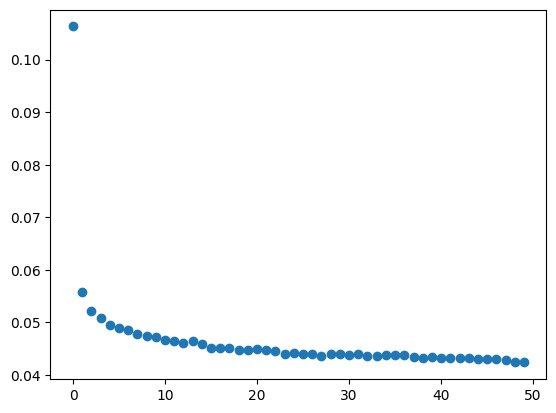

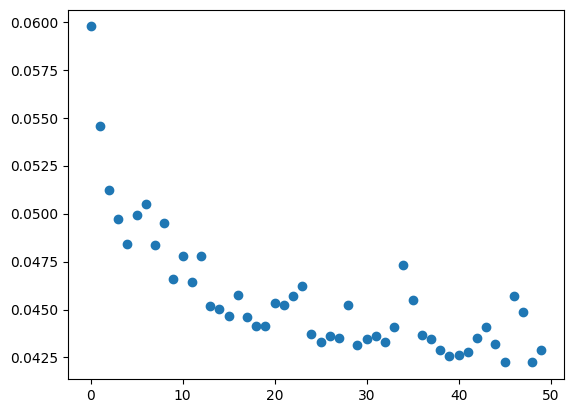

In [7]:
plt.scatter(range(len(history.history['loss'])), history.history['loss'], label='Train Loss')
plt.figure()
plt.scatter(range(len(history.history['val_loss'])), history.history['val_loss'], label='Validation Loss')

In [9]:
model.save('q_auto_encoder.keras')
model.save_weights("q_auto_encoder_weights.h5")


In [8]:
%run audio.ipynb

def detect_anomalies(file_path, model, threshold=0.05):
    # 1. Prep the spectrogram
    spec = generate_fpga_style_spectrogram(file_path) # (64, 313)
    
    # 2. Slice into windows (Batch, 64, 64, 1)
    windows = spectrogram_to_tensor(spec) 
    print(f"Windows Shape: {windows.shape}")
    
    # 3. Model "tries" to reconstruct the sound
    reconstructed = model.predict(windows)
    
    # 4. Calculate error per window
    # Shape of 'errors' will be (Number_of_Windows,)
    errors = np.mean(np.abs(windows - reconstructed), axis=(1, 2, 3))
    
    # 5. Identify which windows are bad
    anomalous_indices = np.where(errors > threshold)[0]
    
    return errors, anomalous_indices

In [11]:
detect_anomalies('../-6_dB_slider/slider/id_00/normal/00000011.wav', model)

Windows Shape: (8, 64, 64, 1)
1/1 [==============================] - 2s 2s/step


(array([0.03950097, 0.0378383 , 0.04169765, 0.03757129, 0.03742032,
        0.03735118, 0.03682462, 0.03595898], dtype=float32),
 array([], dtype=int64))

In [14]:
# Load saved keras model
from qkeras.utils import load_qmodel
model = build_q_tiny_autoencoder()
model.load_weights("q_auto_encoder_weights.h5")

In [15]:
import hls4ml
config = hls4ml.utils.config_from_keras_model(
     model,
     granularity='name',
     default_precision='fixed<8,1>',
     backend='Vitis')

for layer in model.layers:
    config['LayerName'][layer.name] = {
        'Strategy': 'Resource',
        'ReuseFactor': 1
    }


# High reuse on the dense layers - these are the deep template instantiators
config['LayerName']['latent_space']['ReuseFactor'] = 32
config['LayerName']['dec_dense']['ReuseFactor'] = 32

# Also set strategy to Resource instead of Latency for dense layers
# Resource strategy uses far less template nesting
config['LayerName']['latent_space']['Strategy'] = 'Resource'
config['LayerName']['dec_dense']['Strategy'] = 'Resource'

# Adjusting layer specifc number formats based on baseline profiling results to avoid clipping. See image below

# for layer_name, layer_cfg in config['LayerName'].items():
#     if 'weight' in layer_cfg.get('Precision', {}):
#         config['LayerName'][layer_name]['Precision']['weight'] = 'fixed<8,1,TRN,SAT>'
#         config['LayerName'][layer_name]['Precision']['bias']   = 'fixed<8,1,TRN,SAT>'

/home/ericraze/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/tf_keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


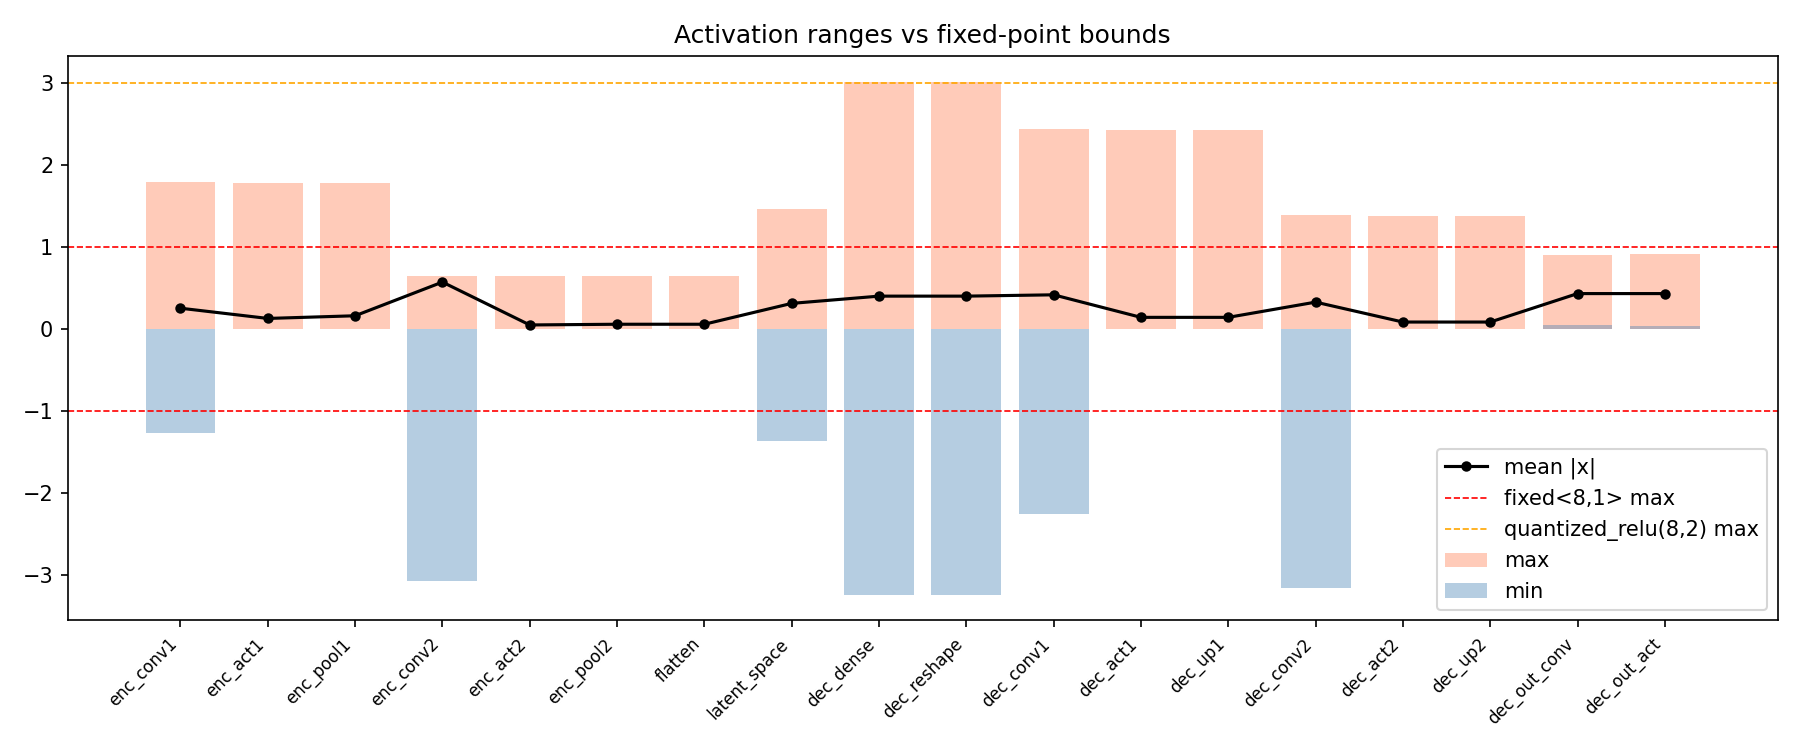

In [ ]:
# some manual cleanup to fix hls4ml bugs
import re

def patch_hls_project(output_dir):
    cpp_path = f'{output_dir}/firmware/myproject.cpp'
    tcl_path = f'{output_dir}/build_prj.tcl'
    
    with open(cpp_path, 'r') as f:
        cpp = f.read()
    
    # Fix all auto& aliases (flatten pattern)
    # Find all occurrences: auto& layerX_out = layerY_out;
    aliases = re.findall(r'auto& (layer\w+_out) = (layer\w+_out);', cpp)
    
    for alias_name, source_name in aliases:
        print(f"Patching alias: {alias_name} → {source_name}")
        
        # Find the depth of the source stream to reuse
        depth_match = re.search(
            rf'#pragma HLS STREAM variable={source_name} depth=(\d+)', cpp
        )
        depth = depth_match.group(1) if depth_match else '256'
        
        # Find the type of the source stream
        type_match = re.search(
            rf'hls::stream<(\w+)> {source_name}', cpp
        )
        stream_type = type_match.group(1) if type_match else 'layer9_t'
        
        old = f'    auto& {alias_name} = {source_name};'
        new = f'''    hls::stream<{stream_type}> {alias_name}("{alias_name}");
    #pragma HLS STREAM variable={alias_name} depth={depth}
    nnet::repack_stream<{stream_type}, {stream_type}, {depth}>({source_name}, {alias_name});'''
        
        cpp = cpp.replace(old, new)
    
    with open(cpp_path, 'w') as f:
        f.write(cpp)
    
    # Patch TCL
    with open(tcl_path, 'r') as f:
        tcl = f.read()
    
    tcl = tcl.replace('catch {config_array_partition -maximum_size $maximum_size}\n', '')
    
    # Disable csim — already validated in Python
    tcl = re.sub(r'(csim_design)', r'#\1', tcl)
    
    with open(tcl_path, 'w') as f:
        f.write(tcl)
    
    print(f"Patched {len(aliases)} alias(es), TCL cleaned")
    return aliases


# Full pipeline in one block
import shutil, os

output_dir = '/mnt/c/hls/src2'
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    output_dir=output_dir,
    io_type='io_stream',
    backend='Vitis',
    part='xc7a35tcsg324-1',
    clock_period=10,
)
hls_model.write()
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True)

# aliases_fixed = patch_hls_project(output_dir)
print("Ready for synthesis")

/home/ericraze/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/tf_keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


Ready for synthesis


In [ ]:
hls_model.compile()

# Get a batch of test windows
X_test = val_data[:100]  # shape (100, 64, 64, 1)

# Keras reference (float32)
keras_out = model.predict(X_test)

# HLS model (fixed-point C++ running on CPU)
hls_out = hls_model.predict(X_test)

4/4 [==============================] - 0s 26ms/step


In [25]:
mae = np.mean(np.abs(keras_out.flatten() - hls_out.flatten()))
max_err = np.max(np.abs(keras_out.flatten() - hls_out.flatten()))
print(f"Mean absolute error: {mae:.6f}")
print(f"Max absolute error:  {max_err:.6f}")

Mean absolute error: 0.282258
Max absolute error:  1.914062
